# 02. 2024·2025년 정류장 공간 비교

이 노트북은 이용량 변화율을 계산하기 전에 2024·2025년 승차 정류장의 좌표와 H3 8 셀 분포를 비교한다.

먼저 두 연도의 정류장을 모두 지도에 표시하고, H3 8 셀별로 2024년·2025년 정류장 존재 여부를 확인한다.

## 셀 1. 라이브러리와 파일 설정

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point, Polygon, mapping
import h3

plt.rcParams['font.family'] = ['Malgun Gothic', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

BASE = Path.cwd()
if BASE.name == 'Analysis':
    BASE = BASE.parent
TRANSPORT = BASE / 'gtx_a_seoul_bus_outputs' / 'transport_card'
ADMIN_PATH = BASE / 'api_cache_gtx_a_routes' / 'HangJeongDong_ver20260701.geojson'
FILE_2024 = TRANSPORT / 'gtx_a_transport_card_20241017_raw_with_coords_api_filled.csv'
FILE_2025 = TRANSPORT / 'gtx_a_transport_card_20251016_raw_with_coords.csv'
H3_RESOLUTION = 8


## 셀 2. 좌표가 있는 승차 정류장 추출

In [2]:
def read_boarding_stops(path, year):
    raw = pd.read_csv(path, encoding='utf-8-sig', low_memory=False)
    # 최종 교통카드 파일의 앞 13개 컬럼은 승차·하차 정류장 정보다.
    df = raw.iloc[:, :13].copy()
    df.columns = ['query_date', 'route_no', 'route_id', 'stop_id', 'stop_name', 'stop_seq',
                  'lat', 'lon', 'goff_stop_id', 'goff_stop_name', 'goff_stop_seq',
                  'goff_lat', 'goff_lon']
    for col in ['route_no', 'route_id', 'stop_name']:
        df[col] = df[col].astype(str).str.strip()
    for col in ['stop_id', 'lat', 'lon']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df = df.dropna(subset=['stop_id', 'lat', 'lon']).copy()
    df['year'] = year
    return df.drop_duplicates(['year', 'route_id', 'stop_id'])

stops24 = read_boarding_stops(FILE_2024, 2024)
stops25 = read_boarding_stops(FILE_2025, 2025)
boarding_stops = pd.concat([stops24, stops25], ignore_index=True)

print(f'2024 좌표 결합 승차 정류장 관측치: {len(stops24):,}건')
print(f'2025 좌표 결합 승차 정류장 관측치: {len(stops25):,}건')
display(boarding_stops.groupby('year')['stop_id'].nunique().rename('고유 승차 정류장 수'))


2024 좌표 결합 승차 정류장 관측치: 363건
2025 좌표 결합 승차 정류장 관측치: 338건


year
2024    228
2025    196
Name: 고유 승차 정류장 수, dtype: int64

## 셀 3. 2024년·2025년 정류장 좌표 지도

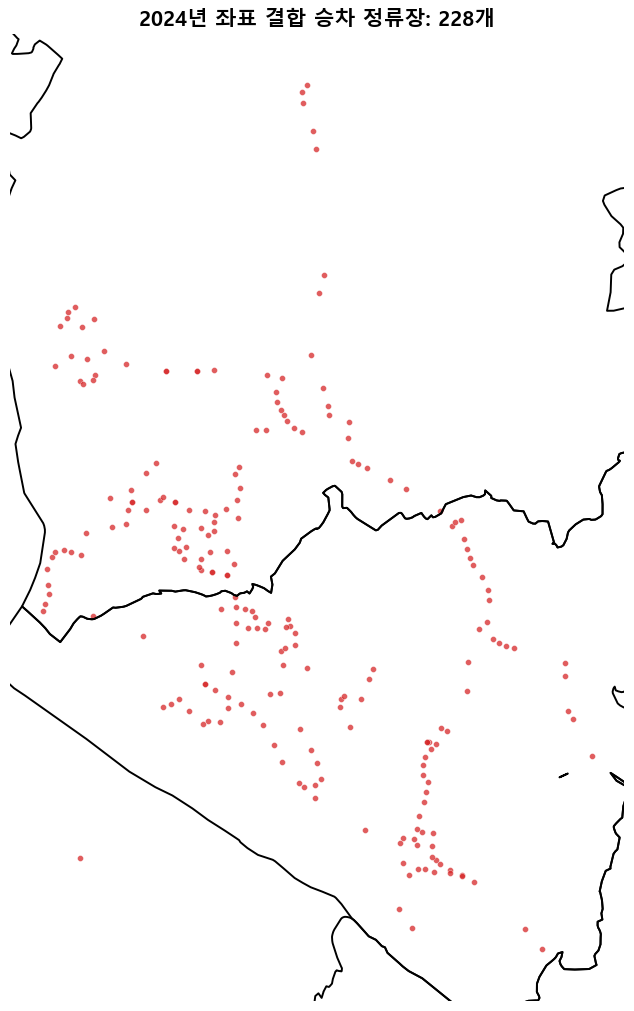

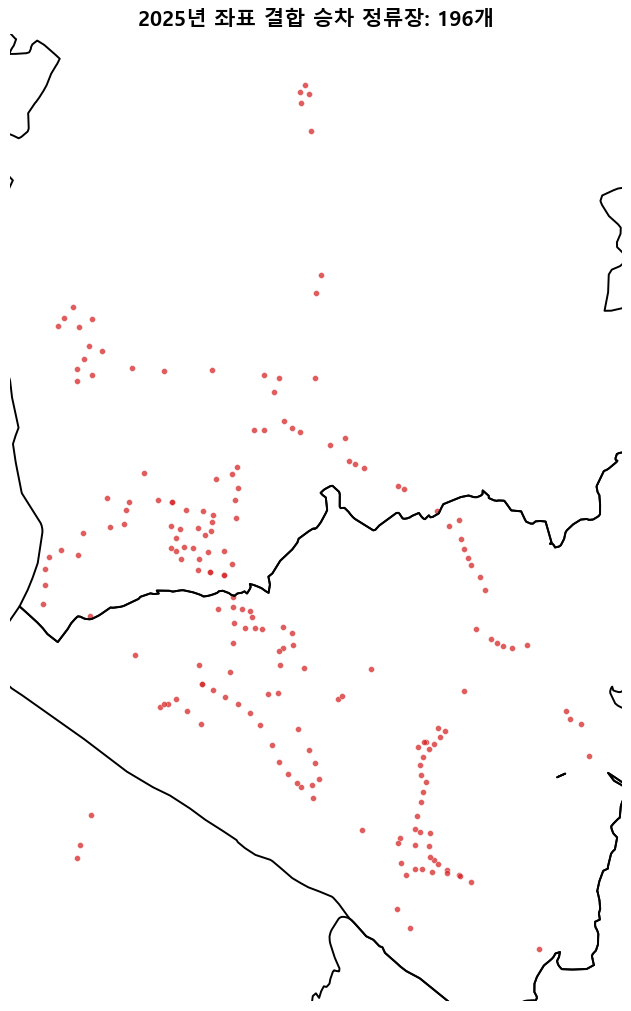

In [3]:
def load_city_boundary():
    if not ADMIN_PATH.exists():
        return None
    admin = gpd.read_file(ADMIN_PATH)
    admin['sgg_code'] = admin['sgg'].astype(str).str.zfill(5)
    admin['city'] = np.select([
        admin['sgg_code'].str.startswith('11'),
        admin['sgg_code'].str.startswith('4128'),
        admin['sgg_code'].str.startswith('4148'),
    ], ['서울', '고양', '파주'], default='연구지역 외')
    return admin[admin['city'] != '연구지역 외'].dissolve(by='city').reset_index()

city_boundary = load_city_boundary()

def plot_stop_points(year):
    points = boarding_stops[boarding_stops['year'] == year].drop_duplicates('stop_id').copy()
    points_gdf = gpd.GeoDataFrame(points, geometry=gpd.points_from_xy(points['lon'], points['lat']), crs='EPSG:4326')
    fig, ax = plt.subplots(figsize=(11, 10), constrained_layout=True)
    if city_boundary is not None:
        city_boundary.boundary.plot(ax=ax, color='black', linewidth=1.4)
    points_gdf.plot(ax=ax, color='#D62728', markersize=18, alpha=0.75,
                    edgecolor='white', linewidth=0.3)
    minx, miny, maxx, maxy = points_gdf.total_bounds
    padx, pady = max((maxx - minx) * 0.06, 0.01), max((maxy - miny) * 0.06, 0.01)
    ax.set_xlim(minx - padx, maxx + padx)
    ax.set_ylim(miny - pady, maxy + pady)
    ax.set_title(f'{year}년 좌표 결합 승차 정류장: {len(points)}개', fontsize=15, fontweight='bold')
    ax.set_axis_off()
    plt.show()

plot_stop_points(2024)
plot_stop_points(2025)


## 셀 4. H3 8 셀별 정류장 존재 여부

In [4]:
def latlon_to_h3(lat, lon, resolution=H3_RESOLUTION):
    if hasattr(h3, 'latlng_to_cell'):
        return h3.latlng_to_cell(float(lat), float(lon), resolution)
    return h3.geo_to_h3(float(lat), float(lon), resolution)

boarding_stops['h3_8'] = [latlon_to_h3(lat, lon) for lat, lon in zip(boarding_stops['lat'], boarding_stops['lon'])]
unique_year_stops = boarding_stops.drop_duplicates(['year', 'stop_id']).copy()

cell_presence = unique_year_stops.groupby(['h3_8', 'year']).agg(
    stop_count=('stop_id', 'nunique'),
    stop_names=('stop_name', lambda x: ' | '.join(sorted(set(x.astype(str)))))
).reset_index()
cell_presence = cell_presence.pivot(index='h3_8', columns='year', values=['stop_count', 'stop_names'])
cell_presence.columns = [f'{metric}_{year}' for metric, year in cell_presence.columns]
cell_presence = cell_presence.fillna({'stop_count_2024': 0, 'stop_count_2025': 0,
                                      'stop_names_2024': '', 'stop_names_2025': ''}).reset_index()
cell_presence['2024_정류장_존재'] = cell_presence['stop_count_2024'] > 0
cell_presence['2025_정류장_존재'] = cell_presence['stop_count_2025'] > 0
cell_presence['셀_상태'] = np.select([
    cell_presence['2024_정류장_존재'] & cell_presence['2025_정류장_존재'],
    cell_presence['2024_정류장_존재'],
    cell_presence['2025_정류장_존재'],
], ['공통 셀', '2024년만 존재', '2025년 신규 셀'], default='미관측 셀')

display(cell_presence['셀_상태'].value_counts().rename('셀 수').to_frame())
display(cell_presence.sort_values(['셀_상태', 'h3_8'])[['h3_8', 'stop_count_2024', 'stop_count_2025', '셀_상태', 'stop_names_2024', 'stop_names_2025']])


C:\Users\금경훈\AppData\Local\Temp\ipykernel_31720\2618127098.py:15: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cell_presence = cell_presence.fillna({'stop_count_2024': 0, 'stop_count_2025': 0,


,셀 수
셀_상태,
공통 셀,113
2024년만 존재,24
2025년 신규 셀,9


,h3_8,stop_count_2024,stop_count_2025,셀_상태,stop_names_2024,stop_names_2025
19,8830e0a591fffff,1,0,2024년만 존재,덕은초.덕양중학교(중),
29,8830e0a633fffff,1,0,2024년만 존재,은행마을3단지.일산자이센트리지.일산자이더헤리티지,
30,8830e0a635fffff,1,0,2024년만 존재,풍3동,
31,8830e0a63dfffff,1,0,2024년만 존재,숲속마을4.5단지,
40,8830e0a683fffff,1,0,2024년만 존재,청대골,
...,...,...,...,...,...,...
141,8830e56b69fffff,1,1,공통 셀,대방아파트,대방아파트
142,8830e578b3fffff,1,1,공통 셀,한진1차.문산역,한진1차.문산역
143,8830e578b7fffff,1,1,공통 셀,봉서2리.붉은밭,봉서2리.붉은밭
144,8830e578bbfffff,2,3,공통 셀,북파주농협.구문산터미널 | 십자약국,문산읍행정복지센터 | 북파주농협.구문산터미널 | 십자약국


## 셀 5. H3 8 셀 상태 지도

C:\Users\금경훈\AppData\Local\Temp\ipykernel_31720\2862870661.py:21: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(title='셀 상태')
C:\Users\금경훈\AppData\Local\Temp\ipykernel_31720\2862870661.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='셀 상태')


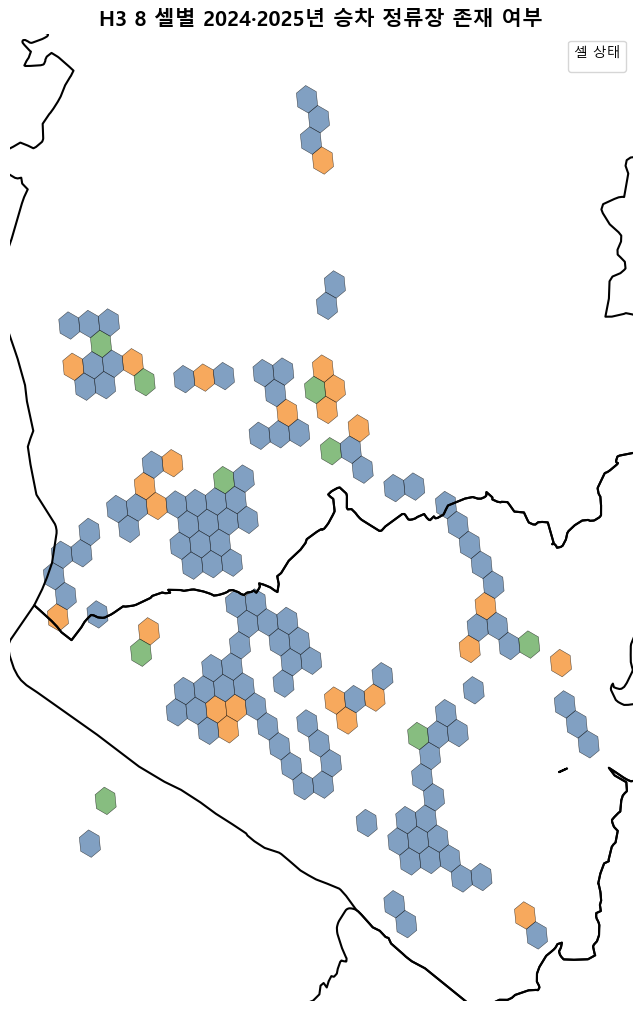

In [5]:
def h3_polygon(cell):
    boundary = h3.cell_to_boundary(cell) if hasattr(h3, 'cell_to_boundary') else h3.h3_to_geo_boundary(cell)
    return Polygon([(lon, lat) for lat, lon in boundary])

status_gdf = gpd.GeoDataFrame(cell_presence.copy(),
    geometry=[h3_polygon(cell) for cell in cell_presence['h3_8']], crs='EPSG:4326')
status_colors = {'공통 셀': '#4C78A8', '2024년만 존재': '#F58518', '2025년 신규 셀': '#54A24B'}
status_gdf['color'] = status_gdf['셀_상태'].map(status_colors).fillna('#DDDDDD')

fig, ax = plt.subplots(figsize=(12, 10), constrained_layout=True)
for status, group in status_gdf.groupby('셀_상태'):
    group.plot(ax=ax, facecolor=status_colors.get(status, '#DDDDDD'), edgecolor='black',
               linewidth=0.35, alpha=0.7, label=status)
if city_boundary is not None:
    city_boundary.boundary.plot(ax=ax, color='black', linewidth=1.5)
minx, miny, maxx, maxy = status_gdf.total_bounds
padx, pady = max((maxx - minx) * 0.06, 0.01), max((maxy - miny) * 0.06, 0.01)
ax.set_xlim(minx - padx, maxx + padx)
ax.set_ylim(miny - pady, maxy + pady)
ax.set_title('H3 8 셀별 2024·2025년 승차 정류장 존재 여부', fontsize=15, fontweight='bold')
ax.legend(title='셀 상태')
ax.set_axis_off()
plt.show()


## 셀 6. 2024년만·2025년 신규 H3 셀의 원인 후보 추적

주황·초록 셀에 어떤 노선과 정류장이 연결되어 있는지 확인한다. 원인은 좌표·정류장명·노선번호를 이용한 1차 후보 분류이며, 최종 판단은 노선 운행 이력 확인이 필요하다.

In [6]:
from math import radians, sin, cos, sqrt, atan2

def normalize_stop_name(value):
    return ''.join(str(value).lower().split()).replace('.', '').replace('-', '')

def distance_m(lat1, lon1, lat2, lon2):
    earth_radius = 6371000
    p1, p2 = radians(float(lat1)), radians(float(lat2))
    dp = radians(float(lat2) - float(lat1))
    dl = radians(float(lon2) - float(lon1))
    a = sin(dp / 2) ** 2 + cos(p1) * cos(p2) * sin(dl / 2) ** 2
    return 2 * earth_radius * atan2(sqrt(a), sqrt(1 - a))

# 셀 상태가 다른 정류장만 원인 후보를 추적한다.
cell_status_map = cell_presence.set_index('h3_8')['셀_상태'].to_dict()
changed_cells = {cell: status for cell, status in cell_status_map.items() if status != '공통 셀'}
year_stops = boarding_stops.drop_duplicates(['year', 'route_no', 'stop_id']).copy()
records = []

for _, row in year_stops[year_stops['h3_8'].isin(changed_cells)].iterrows():
    cell = row['h3_8']
    year = int(row['year'])
    other_year = 2025 if year == 2024 else 2024
    candidates = year_stops[(year_stops['year'] == other_year) & (year_stops['route_no'] == row['route_no'])]
    nearest_distance = np.nan
    same_name = False
    if len(candidates):
        distances = candidates.apply(lambda x: distance_m(row['lat'], row['lon'], x['lat'], x['lon']), axis=1)
        nearest_index = distances.idxmin()
        nearest_distance = float(distances.loc[nearest_index])
        same_name = normalize_stop_name(row['stop_name']) == normalize_stop_name(candidates.loc[nearest_index, 'stop_name'])
    if (same_name or (pd.notna(nearest_distance) and nearest_distance <= 100)):
        cause = '정류장 ID·명칭 변경 후보'
    elif len(candidates):
        cause = '실제 노선/정차 변경 후보'
    else:
        cause = '기타/확인 필요'
    records.append({
        'h3_8': cell,
        '셀 상태': changed_cells[cell],
        '연도': year,
        '노선번호': row['route_no'],
        '정류장ID': int(row['stop_id']),
        '정류장명': row['stop_name'],
        '가장 가까운 반대 연도 정류장 거리(m)': round(nearest_distance, 1) if pd.notna(nearest_distance) else np.nan,
        '원인 후보': cause,
    })

changed_stop_candidates = pd.DataFrame(records)
if len(changed_stop_candidates):
    display(changed_stop_candidates.sort_values(['셀 상태', 'h3_8', '노선번호', '연도']))

cell_cause_rows = []
for cell, group in changed_stop_candidates.groupby('h3_8'):
    causes = set(group['원인 후보'])
    if causes == {'정류장 ID·명칭 변경 후보'}:
        cell_cause = '정류장 ID·명칭 변경 후보'
    elif '실제 노선/정차 변경 후보' in causes:
        cell_cause = '실제 노선/정차 변경 후보'
    else:
        cell_cause = '기타/확인 필요'
    cell_cause_rows.append({
        'H3 셀': cell,
        '상태': group['셀 상태'].iloc[0],
        '관련 노선': ', '.join(sorted(group['노선번호'].astype(str).unique())),
        '2024년 정류장': ' | '.join(group.loc[group['연도'] == 2024, '정류장명'].astype(str).unique()),
        '2025년 정류장': ' | '.join(group.loc[group['연도'] == 2025, '정류장명'].astype(str).unique()),
        '원인 후보': cell_cause,
    })

cell_cause_summary = pd.DataFrame(cell_cause_rows)
display(cell_cause_summary.sort_values(['상태', 'H3 셀']))


,h3_8,셀 상태,연도,노선번호,정류장ID,정류장명,가장 가까운 반대 연도 정류장 거리(m),원인 후보
7,8830e0a591fffff,2024년만 존재,2024,1900,4111380,덕은초.덕양중학교(중),2391.6,실제 노선/정차 변경 후보
15,8830e0a633fffff,2024년만 존재,2024,9600,4111084,은행마을3단지.일산자이센트리지.일산자이더헤리티지,1132.5,실제 노선/정차 변경 후보
8,8830e0a635fffff,2024년만 존재,2024,1900,4106831,풍3동,985.5,실제 노선/정차 변경 후보
6,8830e0a63dfffff,2024년만 존재,2024,1900,4196179,숲속마을4.5단지,253.4,실제 노선/정차 변경 후보
1,8830e0a683fffff,2024년만 존재,2024,1082,4111291,청대골,975.2,실제 노선/정차 변경 후보
0,8830e0a699fffff,2024년만 존재,2024,1082,4115535,두포동.관산동성당,340.8,실제 노선/정차 변경 후보
29,8830e0b413fffff,2024년만 존재,2024,9030,4122743,물향기마을1단지,587.0,실제 노선/정차 변경 후보
30,8830e0b41bfffff,2024년만 존재,2024,9030,4196190,난방공사,671.8,실제 노선/정차 변경 후보
28,8830e0b4c9fffff,2024년만 존재,2024,9030,4175751,오도삼거리,478.5,실제 노선/정차 변경 후보
9,8830e0b553fffff,2024년만 존재,2024,2200,4104969,송운사,245.3,실제 노선/정차 변경 후보


,H3 셀,상태,관련 노선,2024년 정류장,2025년 정류장,원인 후보
2,8830e0a591fffff,2024년만 존재,1900,덕은초.덕양중학교(중),,실제 노선/정차 변경 후보
3,8830e0a633fffff,2024년만 존재,9600,은행마을3단지.일산자이센트리지.일산자이더헤리티지,,실제 노선/정차 변경 후보
4,8830e0a635fffff,2024년만 존재,1900,풍3동,,실제 노선/정차 변경 후보
5,8830e0a63dfffff,2024년만 존재,1900,숲속마을4.5단지,,실제 노선/정차 변경 후보
6,8830e0a683fffff,2024년만 존재,1082,청대골,,실제 노선/정차 변경 후보
7,8830e0a699fffff,2024년만 존재,1082,두포동.관산동성당,,실제 노선/정차 변경 후보
8,8830e0b413fffff,2024년만 존재,9030,물향기마을1단지,,실제 노선/정차 변경 후보
9,8830e0b41bfffff,2024년만 존재,9030,난방공사,,실제 노선/정차 변경 후보
10,8830e0b4c9fffff,2024년만 존재,9030,오도삼거리,,실제 노선/정차 변경 후보
12,8830e0b553fffff,2024년만 존재,2200,송운사,,실제 노선/정차 변경 후보


## 셀 7. H3 8 셀별 노선 구성 변화 비교

정류장 ID가 아니라 노선번호 집합을 기준으로 2024·2025년의 노선 구성을 비교한다. 공통 셀이라도 노선 집합이 달라지면 노선구성 변경 셀로 분류한다.

In [7]:
# 동일 연도·노선·정류장은 한 번만 사용하고, 노선번호 기준으로 집합을 만든다.
route_cell_stops = boarding_stops.drop_duplicates(['year', 'route_no', 'stop_id']).copy()
route_cell_sets = route_cell_stops.groupby(['h3_8', 'year'])['route_no'].agg(lambda x: set(x.astype(str))).unstack(fill_value=None)
for year in [2024, 2025]:
    if year not in route_cell_sets.columns:
        route_cell_sets[year] = None

route_cell_sets[2024] = route_cell_sets[2024].apply(lambda x: x if isinstance(x, set) else set())
route_cell_sets[2025] = route_cell_sets[2025].apply(lambda x: x if isinstance(x, set) else set())
route_cell_sets['추가된 노선'] = route_cell_sets.apply(lambda row: sorted(row[2025] - row[2024], key=str), axis=1)
route_cell_sets['제외된 노선'] = route_cell_sets.apply(lambda row: sorted(row[2024] - row[2025], key=str), axis=1)
route_cell_sets['노선구성 변경 여부'] = ((route_cell_sets['추가된 노선'].map(len) > 0) | (route_cell_sets['제외된 노선'].map(len) > 0)).astype(int)

route_composition = route_cell_sets.reset_index()[['h3_8', 2024, 2025, '추가된 노선', '제외된 노선', '노선구성 변경 여부']].copy()
route_composition = route_composition.rename(columns={2024: '2024 노선 목록', 2025: '2025 노선 목록'})
for col in ['2024 노선 목록', '2025 노선 목록']:
    route_composition[col] = route_composition[col].map(lambda x: ', '.join(sorted(x, key=str)) if x else '-')
for col in ['추가된 노선', '제외된 노선']:
    route_composition[col] = route_composition[col].map(lambda x: ', '.join(x) if x else '-')

# 기존의 2024년만 존재·2025년 신규·공통 셀 상태를 결합한다.
final_h3_cell_table = route_composition.merge(
    cell_presence[['h3_8', '셀_상태', 'stop_count_2024', 'stop_count_2025']],
    on='h3_8', how='left'
).rename(columns={
    'h3_8': 'H3 셀',
    '셀_상태': '기존 셀 상태',
    'stop_count_2024': '2024 정류장 수',
    'stop_count_2025': '2025 정류장 수',
})
final_h3_cell_table['최종 셀 상태'] = np.select([
    final_h3_cell_table['노선구성 변경 여부'].eq(1),
    final_h3_cell_table['기존 셀 상태'].eq('2025년 신규 셀'),
    final_h3_cell_table['기존 셀 상태'].eq('2024년만 존재'),
], ['노선구성 변경 셀', '2025년 신규 셀', '2024년만 존재 셀'], default='노선구성 유지 셀')

final_h3_cell_table = final_h3_cell_table.sort_values(['노선구성 변경 여부', '기존 셀 상태', 'H3 셀'], ascending=[False, True, True]).reset_index(drop=True)
display(final_h3_cell_table)
display(final_h3_cell_table['최종 셀 상태'].value_counts().rename('셀 수').to_frame())


,H3 셀,2024 노선 목록,2025 노선 목록,추가된 노선,제외된 노선,노선구성 변경 여부,기존 셀 상태,2024 정류장 수,2025 정류장 수,최종 셀 상태
0,8830e0a591fffff,1900,-,-,1900,1,2024년만 존재,1,0,노선구성 변경 셀
1,8830e0a633fffff,9600,-,-,9600,1,2024년만 존재,1,0,노선구성 변경 셀
2,8830e0a635fffff,1900,-,-,1900,1,2024년만 존재,1,0,노선구성 변경 셀
3,8830e0a63dfffff,1900,-,-,1900,1,2024년만 존재,1,0,노선구성 변경 셀
4,8830e0a683fffff,1082,-,-,1082,1,2024년만 존재,1,0,노선구성 변경 셀
...,...,...,...,...,...,...,...,...,...,...
141,8830e56b69fffff,9709,9709,-,-,0,공통 셀,1,1,노선구성 유지 셀
142,8830e578b3fffff,9710,9710,-,-,0,공통 셀,1,1,노선구성 유지 셀
143,8830e578b7fffff,9710,9710,-,-,0,공통 셀,1,1,노선구성 유지 셀
144,8830e578bbfffff,9710,9710,-,-,0,공통 셀,2,3,노선구성 유지 셀


,셀 수
최종 셀 상태,
노선구성 유지 셀,88
노선구성 변경 셀,58


## 셀 8. H3 8 셀별 공급구조 변화 유형 분류

노선번호 집합을 기준으로 6개 공급구조 변화 유형을 분류하고, 노선 목록이 같더라도 정류장 ID 또는 정류장 수가 달라진 경우를 별도로 표시한다.

In [8]:
# H3 8 전체 후보 셀: 2024년 또는 2025년에 좌표가 있는 정류장이 속한 셀
all_h3_cells = sorted(set(route_cell_sets.index), key=str)
rows = []

# 정류장 ID가 달라도 정류장명과 H3 셀이 같으면 동일 정류장으로 간주한다.
import re
import unicodedata

def normalize_stop_name_for_compare(value):
    text = unicodedata.normalize('NFKC', str(value)).lower()
    text = re.sub(r'\s+', '', text)
    text = re.sub(r'[.·\-_/(),]', '', text)
    return text

stop_id_cell_sets = unique_year_stops.groupby(['h3_8', 'year'])['stop_id'].agg(lambda x: set(x.astype(int))).unstack(fill_value=None)
for year in [2024, 2025]:
    if year not in stop_id_cell_sets.columns:
        stop_id_cell_sets[year] = None

stop_name_cell_lists = {}
for (cell, year), group in unique_year_stops.groupby(['h3_8', 'year']):
    names = [normalize_stop_name_for_compare(name) for name in group['stop_name'].dropna()]
    stop_name_cell_lists[(cell, year)] = sorted(names)

for cell in all_h3_cells:
    routes_24 = route_cell_sets.loc[cell, 2024] if cell in route_cell_sets.index else set()
    routes_25 = route_cell_sets.loc[cell, 2025] if cell in route_cell_sets.index else set()
    routes_24 = routes_24 if isinstance(routes_24, set) else set()
    routes_25 = routes_25 if isinstance(routes_25, set) else set()
    stops_24 = stop_id_cell_sets.loc[cell, 2024] if cell in stop_id_cell_sets.index else set()
    stops_25 = stop_id_cell_sets.loc[cell, 2025] if cell in stop_id_cell_sets.index else set()
    stops_24 = stops_24 if isinstance(stops_24, set) else set()
    stops_25 = stops_25 if isinstance(stops_25, set) else set()
    names_24 = stop_name_cell_lists.get((cell, 2024), [])
    names_25 = stop_name_cell_lists.get((cell, 2025), [])

    if not routes_24 and routes_25:
        route_type = '2025 신규 셀'
    elif routes_24 and not routes_25:
        route_type = '2025 소멸 셀'
    elif routes_24 == routes_25:
        route_type = '완전 동일'
    elif routes_24 < routes_25:
        route_type = '노선 추가'
    elif routes_25 < routes_24:
        route_type = '노선 제외'
    else:
        route_type = '노선 교체'

    rows.append({
        'H3 셀': cell,
        '2024 노선': ', '.join(sorted(routes_24, key=str)) if routes_24 else '-',
        '2025 노선': ', '.join(sorted(routes_25, key=str)) if routes_25 else '-',
        '노선변경 유형': route_type,
        '2024 정류장 수': len(stops_24),
        '2025 정류장 수': len(stops_25),
        '정류장구성 변경 여부': int(names_24 != names_25 or len(names_24) != len(names_25)),
    })

supply_structure_table = pd.DataFrame(rows)
route_type_order = ['완전 동일', '노선 추가', '노선 제외', '노선 교체', '2025 신규 셀', '2025 소멸 셀']
supply_structure_table['노선변경 유형'] = pd.Categorical(supply_structure_table['노선변경 유형'], categories=route_type_order, ordered=True)
supply_structure_table = supply_structure_table.sort_values(['노선변경 유형', 'H3 셀']).reset_index(drop=True)

display(supply_structure_table)
type_summary = supply_structure_table['노선변경 유형'].value_counts().reindex(route_type_order, fill_value=0).rename('셀 수').to_frame()
display(type_summary)

stop_change_summary = supply_structure_table.groupby('노선변경 유형', observed=False)['정류장구성 변경 여부'].agg(['sum', 'count']).rename(columns={'sum': '정류장구성 변경 셀 수', 'count': '전체 셀 수'})
display(stop_change_summary)

OUTPUT_DIR = BASE / 'Analysis' / 'output'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 한글이 깨지지 않도록 UTF-8 BOM 형식으로 저장한다.
cell_presence.to_csv(OUTPUT_DIR / 'h3_8_cell_presence.csv', index=False, encoding='utf-8-sig')
changed_stop_candidates.to_csv(OUTPUT_DIR / 'h3_8_changed_stop_candidates.csv', index=False, encoding='utf-8-sig')
supply_structure_table.to_csv(OUTPUT_DIR / 'h3_8_supply_structure_by_cell.csv', index=False, encoding='utf-8-sig')
print(f'CSV 저장 완료: {OUTPUT_DIR}')


,H3 셀,2024 노선,2025 노선,노선변경 유형,2024 정류장 수,2025 정류장 수,정류장구성 변경 여부
0,8830e0a2e3fffff,6701,6701,완전 동일,1,2,1
1,8830e0a407fffff,9600,9600,완전 동일,1,1,0
2,8830e0a419fffff,"1082, 9600","1082, 9600",완전 동일,2,2,0
3,8830e0a41dfffff,"1082, 1900, 9600","1082, 1900, 9600",완전 동일,3,3,0
4,8830e0a423fffff,"1082, 9600","1082, 9600",완전 동일,2,2,0
...,...,...,...,...,...,...,...
141,8830e56a5dfffff,9710,-,2025 소멸 셀,1,0,1
142,8830e56b15fffff,9710,-,2025 소멸 셀,1,0,1
143,8830e56b2bfffff,"7101, 9709",-,2025 소멸 셀,3,0,1
144,8830e56b31fffff,9710,-,2025 소멸 셀,2,0,1


,셀 수
노선변경 유형,
완전 동일,88
노선 추가,13
노선 제외,10
노선 교체,2
2025 신규 셀,9
2025 소멸 셀,24


,정류장구성 변경 셀 수,전체 셀 수
노선변경 유형,,
완전 동일,19,88
노선 추가,3,13
노선 제외,3,10
노선 교체,1,2
2025 신규 셀,9,9
2025 소멸 셀,24,24


CSV 저장 완료: C:\Users\금경훈\Desktop\Gachon\3-2\UROP\Analysis\output


## 셀 9. 노선 동일·정류장 구성 변경 셀 상세 비교

노선변경 유형이 완전 동일하지만 정류장구성 변경 여부가 1인 셀만 추출한다. 정류장명이 같은데 ID만 달라진 경우는 별도로 표시한다.

In [9]:
target_cells = supply_structure_table[
    (supply_structure_table['노선변경 유형'] == '완전 동일')
    & (supply_structure_table['정류장구성 변경 여부'] == 1)
].copy()

def stop_id_name_text(group):
    pairs = group[['stop_id', 'stop_name']].drop_duplicates('stop_id').sort_values('stop_id')
    return ' | '.join(f"{int(row.stop_id)}: {row.stop_name}" for row in pairs.itertuples()) if len(pairs) else '-'

detail_rows = []
for cell in target_cells['H3 셀']:
    cell_stops = unique_year_stops[unique_year_stops['h3_8'] == cell]
    stops24 = cell_stops[cell_stops['year'] == 2024].copy()
    stops25 = cell_stops[cell_stops['year'] == 2025].copy()
    names24 = {}
    names25 = {}
    for _, row in stops24.drop_duplicates('stop_id').iterrows():
        names24.setdefault(normalize_stop_name_for_compare(row['stop_name']), []).append((int(row['stop_id']), str(row['stop_name'])))
    for _, row in stops25.drop_duplicates('stop_id').iterrows():
        names25.setdefault(normalize_stop_name_for_compare(row['stop_name']), []).append((int(row['stop_id']), str(row['stop_name'])))
    same_name_id_changes = []
    for normalized_name in sorted(set(names24) & set(names25)):
        ids24 = sorted({item[0] for item in names24[normalized_name]})
        ids25 = sorted({item[0] for item in names25[normalized_name]})
        if ids24 != ids25:
            display_name = names24[normalized_name][0][1]
            same_name_id_changes.append(f"{display_name}: 2024 {ids24} → 2025 {ids25}")
    detail_rows.append({
        'H3 셀': cell,
        '관련 노선': target_cells.loc[target_cells['H3 셀'] == cell, '2024 노선'].iloc[0],
        '2024 정류장 ID·명': stop_id_name_text(stops24),
        '2025 정류장 ID·명': stop_id_name_text(stops25),
        'ID는 다르지만 정류장명 동일': ' | '.join(same_name_id_changes) if same_name_id_changes else '-',
    })

same_route_stop_change_detail = pd.DataFrame(detail_rows).sort_values('H3 셀').reset_index(drop=True)
print(f'대상 셀 수: {len(same_route_stop_change_detail)}개')
display(same_route_stop_change_detail)
same_route_stop_change_detail.to_csv(OUTPUT_DIR / 'h3_8_same_route_stop_change_detail.csv', index=False, encoding='utf-8-sig')


대상 셀 수: 19개


,H3 셀,관련 노선,2024 정류장 ID·명,2025 정류장 ID·명,ID는 다르지만 정류장명 동일
0,8830e0a2e3fffff,6701,4115322: 홈플러스.산림조합,4115322: 홈플러스.산림조합 | 4116348: 한국아파트,-
1,8830e0a641fffff,1200,4110813: 홀트학교 | 4110818: 탄현마을5.6단지 | 4110822: ...,4110818: 탄현마을5.6단지 | 4110822: 탄현2단지.삼익아파트 | 41...,-
2,8830e0a643fffff,"1200, M7412",4108024: 중산마을1.2단지 | 4110828: 중산마을2단지.해태쇼핑.코오롱...,4110828: 중산마을2단지.해태쇼핑.코오롱아파트,-
3,8830e0a6a5fffff,"1082, 9600",4111304: 고양시청 | 4111305: 고양시청 | 4177969: 원당연세병...,4111305: 고양시청 | 4177969: 원당연세병원 | 4177971: 세창짜...,"고양시청: 2024 [4111304, 4111305] → 2025 [4111305]"
4,8830e0a6edfffff,9600,4177481: 위시티주상복합단지 | 4177488: 위시티3.4단지,4177488: 위시티3.4단지,-
5,8830e0b405fffff,"2200, 9030-1",4104776: 출판단지삼거리 | 4104952: 롯데프리미엄아울렛 | 419565...,4104776: 출판단지삼거리 | 4104952: 롯데프리미엄아울렛,-
6,8830e0b411fffff,"9030, M7154",4195587: 청석마을8단지 | 4195596: 청석마을8단지 | 4196192:...,4195587: 청석마을8단지 | 4196192: 청석마을9단지,"청석마을8단지: 2024 [4195587, 4195596] → 2025 [4195587]"
7,8830e0b42dfffff,2200,4104046: 북센정문 | 4115902: 북센후문,4104046: 북센정문,-
8,8830e0b463fffff,"2200, 9030-1",4105161: 이채쇼핑몰 | 4175734: 심학교,4105161: 이채쇼핑몰,-
9,8830e0b4a9fffff,"1500, 3100, 9030, G7426, G7625, M7111, M7154",4104781: 한빛마을3.6단지 | 4104782: 한빛마을3.6단지 | 4104...,4104781: 한빛마을3.6단지 | 4104782: 한빛마을3.6단지 | 4104...,-


## 셀 10. 정류장명·좌표 기준 정류장 구성 재판정

정류장 ID 변경과 실제 정류장 추가·제외를 구분하여 정류장구성 변경 여부를 다시 계산한다.

In [10]:
# 직전 ID 기준 판정을 보존하여 판정이 바뀐 셀을 확인한다.
previous_stop_flag = supply_structure_table.set_index('H3 셀')['정류장구성 변경 여부'].astype(int).to_dict()
MATCH_DISTANCE_M = 100

def classify_stop_configuration(cell):
    before = unique_year_stops[(unique_year_stops['h3_8'] == cell) & (unique_year_stops['year'] == 2024)].drop_duplicates('stop_id').copy()
    after = unique_year_stops[(unique_year_stops['h3_8'] == cell) & (unique_year_stops['year'] == 2025)].drop_duplicates('stop_id').copy()
    before['name_key'] = before['stop_name'].map(normalize_stop_name_for_compare)
    after['name_key'] = after['stop_name'].map(normalize_stop_name_for_compare)

    # 같은 셀·같은 정류장명은 ID가 달라도 동일 정류장으로 매칭한다.
    common_names = set(before['name_key']) & set(after['name_key'])
    before_unmatched = before[~before['name_key'].isin(common_names)].copy()
    after_unmatched = after[~after['name_key'].isin(common_names)].copy()
    coordinate_matches = []

    # 이름이 바뀐 경우에만 가장 가까운 위치를 1:1로 매칭한다.
    while len(before_unmatched) and len(after_unmatched):
        pairs = []
        for before_idx, before_row in before_unmatched.iterrows():
            for after_idx, after_row in after_unmatched.iterrows():
                pairs.append((distance_m(before_row['lat'], before_row['lon'], after_row['lat'], after_row['lon']), before_idx, after_idx))
        distance, before_idx, after_idx = min(pairs, key=lambda x: x[0])
        if distance <= MATCH_DISTANCE_M:
            coordinate_matches.append((before_idx, after_idx, distance))
            before_unmatched = before_unmatched.drop(index=before_idx)
            after_unmatched = after_unmatched.drop(index=after_idx)
        else:
            break

    changed = int(len(before_unmatched) > 0 or len(after_unmatched) > 0)
    if not len(before) and len(after):
        reason = '2025 신규 정류장'
    elif len(before) and not len(after):
        reason = '2025 소멸 정류장'
    elif changed:
        reason = '실제 정류장 추가·제외 또는 위치 변경'
    elif coordinate_matches:
        reason = '동일 위치 명칭 변경'
    elif common_names:
        reason = '정류장명 동일 또는 ID 변경'
    else:
        reason = '정류장 구성 동일'
    return changed, reason

reclassified = []
for cell in supply_structure_table['H3 셀']:
    changed, reason = classify_stop_configuration(cell)
    reclassified.append({'H3 셀': cell, '정류장구성 변경 여부': changed, '정류장 구성 판정 근거': reason})
reclassified = pd.DataFrame(reclassified)

supply_structure_table = supply_structure_table.drop(columns=['정류장구성 변경 여부']).merge(reclassified, on='H3 셀', how='left')
supply_structure_table['정류장구성 변경 여부'] = supply_structure_table['정류장구성 변경 여부'].astype(int)

print('최종 정류장구성 변경 여부 0/1 셀 수')
display(supply_structure_table['정류장구성 변경 여부'].value_counts().sort_index().rename('셀 수').to_frame())
# 현재 표의 2024·2025 노선 목록을 직접 비교해 노선구성 변경 여부를 계산한다.
route_change_flag = (supply_structure_table.iloc[:, 1].astype(str) != supply_structure_table.iloc[:, 2].astype(str)).astype(int)
supply_structure_table['노선구성 변경 여부'] = route_change_flag
stable_supply = supply_structure_table[
    (supply_structure_table['노선구성 변경 여부'] == 0)
    & (supply_structure_table['정류장구성 변경 여부'] == 0)
]
print(f'노선구성 변경=0 AND 정류장구성 변경=0인 공급구조 완전 유지 셀 수: {len(stable_supply)}개')

changed_judgement = supply_structure_table.merge(
    pd.Series(previous_stop_flag, name='기존 정류장구성 변경 여부'),
    left_on='H3 셀', right_index=True, how='left'
)
changed_judgement = changed_judgement[
    changed_judgement['기존 정류장구성 변경 여부'] != changed_judgement['정류장구성 변경 여부']
].sort_values('H3 셀')
print(f'기존 판정에서 변경된 셀 수: {len(changed_judgement)}개')
display(changed_judgement[['H3 셀', '기존 정류장구성 변경 여부', '정류장구성 변경 여부', '정류장 구성 판정 근거', '2024 정류장 수', '2025 정류장 수']])

supply_structure_table.to_csv(OUTPUT_DIR / 'h3_8_supply_structure_by_cell.csv', index=False, encoding='utf-8-sig')
changed_judgement.to_csv(OUTPUT_DIR / 'h3_8_stop_configuration_rejudged_cells.csv', index=False, encoding='utf-8-sig')


최종 정류장구성 변경 여부 0/1 셀 수


,셀 수
정류장구성 변경 여부,
0,90
1,56


노선구성 변경=0 AND 정류장구성 변경=0인 공급구조 완전 유지 셀 수: 71개
기존 판정에서 변경된 셀 수: 3개


,H3 셀,기존 정류장구성 변경 여부,정류장구성 변경 여부,정류장 구성 판정 근거,2024 정류장 수,2025 정류장 수
38,8830e0b411fffff,1,0,정류장명 동일 또는 ID 변경,3,2
49,8830e0b4c5fffff,1,0,정류장명 동일 또는 ID 변경,4,3
109,8830e0b695fffff,1,0,정류장명 동일 또는 ID 변경,2,1


## 셀 11. 공급구조 유지 셀의 승차인원 변화 분석

노선구성 변경 여부와 정류장구성 변경 여부가 모두 0인 H3 8 셀만 대상으로 2024·2025년 승차인원 증감을 계산한다. 지도에는 행정경계를 표시하지 않고 안정 셀만 표시한다.

공급구조 유지 분석 셀 수: 71개
2024년 승차인원 0인 셀 수: 0개


,H3 셀,2024 승차인원,2025 승차인원,승차인원 증감
0,8830e0a407fffff,9,14,5
1,8830e0a419fffff,31,11,-20
2,8830e0a41dfffff,211,165,-46
3,8830e0a423fffff,14,8,-6
4,8830e0a42bfffff,25,10,-15
...,...,...,...,...
66,8830e56b2dfffff,12,14,2
67,8830e56b69fffff,10,8,-2
68,8830e578b3fffff,5,6,1
69,8830e578b7fffff,3,9,6


71개 공급구조 유지 셀 요약통계


,count,mean,std,min,25%,50%,75%,max,중앙값
2024 승차인원,71.0,242.86,351.71,1.0,17.0,91.0,320.0,1994.0,91.0
2025 승차인원,71.0,193.82,305.50,2.0,11.0,92.0,244.5,1602.0,92.0
승차인원 증감,71.0,-49.04,161.93,-612.0,-85.0,-9.0,5.5,706.0,-9.0


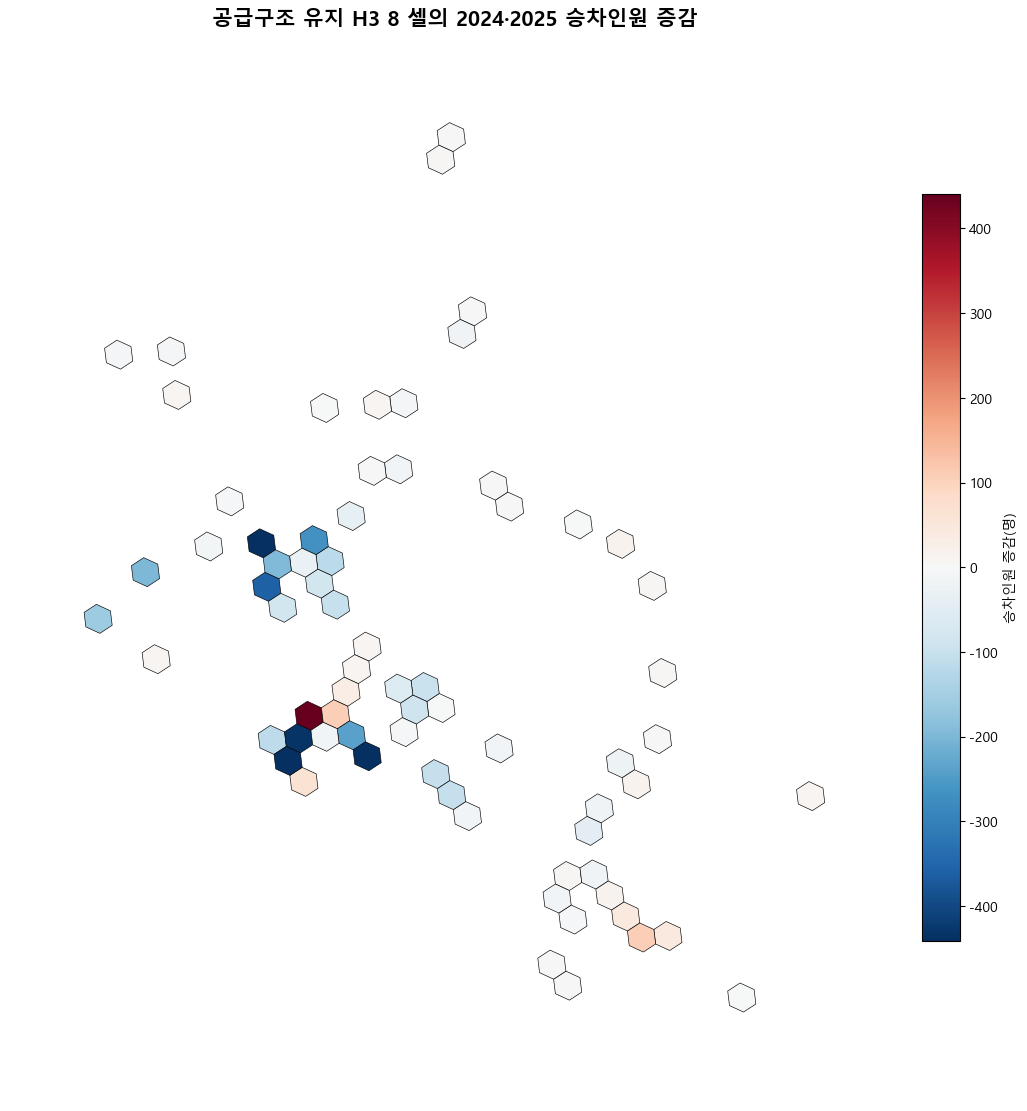

In [11]:
# 최종 공급구조 유지 셀 71개 추출
stable_cells = supply_structure_table.loc[
    (supply_structure_table['노선구성 변경 여부'] == 0)
    & (supply_structure_table['정류장구성 변경 여부'] == 0),
    'H3 셀'
].tolist()

def boarding_demand_from_file(path):
    raw = pd.read_csv(path, encoding='utf-8-sig', low_memory=False)
    stop_id = pd.to_numeric(raw.iloc[:, 22], errors='coerce')
    users = pd.to_numeric(raw.iloc[:, 27], errors='coerce').fillna(0)
    return pd.DataFrame({'stop_id': stop_id, 'boarding_users': users}).dropna(subset=['stop_id']).groupby('stop_id')['boarding_users'].sum()

demand24 = boarding_demand_from_file(FILE_2024)
demand25 = boarding_demand_from_file(FILE_2025)
boarding_for_change = boarding_stops.drop_duplicates(['year', 'stop_id']).copy()
boarding_for_change['boarding_users'] = boarding_for_change.apply(
    lambda row: (demand24 if row['year'] == 2024 else demand25).get(row['stop_id'], 0), axis=1
)

cell_year_demand = boarding_for_change.groupby(['h3_8', 'year'])['boarding_users'].sum().unstack(fill_value=0)
for year in [2024, 2025]:
    if year not in cell_year_demand.columns:
        cell_year_demand[year] = 0
stable_demand = cell_year_demand.reindex(stable_cells, fill_value=0)[[2024, 2025]].copy()
stable_demand.columns = ['2024 승차인원', '2025 승차인원']
stable_demand['승차인원 증감'] = stable_demand['2025 승차인원'] - stable_demand['2024 승차인원']
stable_demand = stable_demand.reset_index().rename(columns={'h3_8': 'H3 셀'})

print(f'공급구조 유지 분석 셀 수: {len(stable_demand)}개')
print(f'2024년 승차인원 0인 셀 수: {(stable_demand["2024 승차인원"] == 0).sum()}개')
display(stable_demand)

summary_statistics = stable_demand[['2024 승차인원', '2025 승차인원', '승차인원 증감']].describe().T
summary_statistics['중앙값'] = stable_demand[['2024 승차인원', '2025 승차인원', '승차인원 증감']].median()
print('71개 공급구조 유지 셀 요약통계')
display(summary_statistics.round(2))

# 안정 셀별 승차인원 증감 지도: 행정경계 없이 H3 셀 범위만 사용한다.
stable_map = gpd.GeoDataFrame(
    stable_demand.copy(),
    geometry=[h3_polygon(cell) for cell in stable_demand['H3 셀']],
    crs='EPSG:4326'
)
valid_change = stable_map['승차인원 증감'].dropna()
change_limit = max(1, float(np.nanpercentile(np.abs(valid_change), 95))) if len(valid_change) else 1
from matplotlib.colors import TwoSlopeNorm
change_norm = TwoSlopeNorm(vmin=-change_limit, vcenter=0, vmax=change_limit)

fig, ax = plt.subplots(figsize=(13, 11), constrained_layout=True)
stable_map.plot(ax=ax, column='승차인원 증감', cmap='RdBu_r', norm=change_norm,
                 edgecolor='black', linewidth=0.45, legend=True,
                 legend_kwds={'label': '승차인원 증감(명)', 'shrink': 0.7, 'pad': 0.02})
zero_baseline = stable_map[stable_map['2024 승차인원'] == 0]
if len(zero_baseline):
    zero_baseline.plot(ax=ax, facecolor='#BDBDBD', edgecolor='black', hatch='///', linewidth=0.8)
minx, miny, maxx, maxy = stable_map.total_bounds
padx = max((maxx - minx) * 0.10, 0.015)
pady = max((maxy - miny) * 0.10, 0.015)
ax.set_xlim(minx - padx, maxx + padx)
ax.set_ylim(miny - pady, maxy + pady)
ax.set_aspect('equal')
ax.set_title('공급구조 유지 H3 8 셀의 2024·2025 승차인원 증감', fontsize=15, fontweight='bold')
ax.set_axis_off()
plt.show()

stable_demand.to_csv(OUTPUT_DIR / 'h3_8_stable_supply_demand_change.csv', index=False, encoding='utf-8-sig')


## 셀 12. 안정 셀의 증감 방향과 증감 극단값 확인

공급구조가 유지된 71개 H3 셀을 승차인원 증감 방향으로 분류하고, 증감량이 가장 큰·작은 셀의 낮은 기저수요 여부를 확인한다.

In [12]:
direction_table = stable_demand.copy()
direction_table['증감 방향'] = np.select([
    direction_table['승차인원 증감'] < 0,
    direction_table['승차인원 증감'] == 0,
    direction_table['승차인원 증감'] > 0,
], ['감소', '변화 없음', '증가'], default='확인 필요')
direction_summary = direction_table['증감 방향'].value_counts().reindex(['감소', '변화 없음', '증가'], fill_value=0).rename('셀 수').to_frame()
direction_summary['비율(%)'] = direction_summary['셀 수'] / len(direction_table) * 100
print('공급구조 유지 71개 셀의 승차인원 증감 방향')
display(direction_summary.round(2))

valid_extreme = stable_demand.dropna(subset=['승차인원 증감']).copy()
extreme_columns = ['H3 셀', '2024 승차인원', '2025 승차인원', '승차인원 증감']
largest_5 = valid_extreme.nlargest(5, '승차인원 증감')[extreme_columns].copy()
smallest_5 = valid_extreme.nsmallest(5, '승차인원 증감')[extreme_columns].copy()
largest_5['2024 저수요 여부(30명 이하)'] = largest_5['2024 승차인원'] <= 30
smallest_5['2024 저수요 여부(30명 이하)'] = smallest_5['2024 승차인원'] <= 30
print('승차인원 증감이 가장 큰 5개 셀')
display(largest_5.round(2))
print('승차인원 증감이 가장 작은 5개 셀')
display(smallest_5.round(2))

extreme_cells = pd.concat([
    largest_5.assign(극단값_구분='증감 상위 5개'),
    smallest_5.assign(극단값_구분='증감 하위 5개'),
], ignore_index=True)
print(f'극단값 10개 중 2024년 승차인원 30명 이하 셀: {(extreme_cells["2024 저수요 여부(30명 이하)"]).sum()}개')
extreme_cells.to_csv(OUTPUT_DIR / 'h3_8_stable_extreme_change_cells.csv', index=False, encoding='utf-8-sig')


공급구조 유지 71개 셀의 승차인원 증감 방향


,셀 수,비율(%)
증감 방향,,
감소,43,60.56
변화 없음,2,2.82
증가,26,36.62


승차인원 증감이 가장 큰 5개 셀


,H3 셀,2024 승차인원,2025 승차인원,승차인원 증감,2024 저수요 여부(30명 이하)
47,8830e0b595fffff,896,1602,706,False
14,8830e0a5ddfffff,302,412,110,False
48,8830e0b597fffff,236,343,107,False
49,8830e0b5b5fffff,882,945,63,False
13,8830e0a5d1fffff,63,107,44,False


승차인원 증감이 가장 작은 5개 셀


,H3 셀,2024 승차인원,2025 승차인원,승차인원 증감,2024 저수요 여부(30명 이하)
52,8830e0b5bdfffff,1036,424,-612,False
40,8830e0b4c5fffff,781,286,-495,False
25,8830e0a665fffff,1994,1543,-451,False
50,8830e0b5b9fffff,1123,692,-431,False
42,8830e0b4e1fffff,1068,707,-361,False


극단값 10개 중 2024년 승차인원 30명 이하 셀: 0개


## 셀 13. 고양·파주 전체 H3 8 셀과 안정 셀 증감 지도

고양시·파주시 전체를 H3 8 셀로 채우고, 승차인원이 있는 공급구조 유지 셀만 승차인원 증감 색상으로 표시한다. 서울 행정경계는 표시하지 않는다.

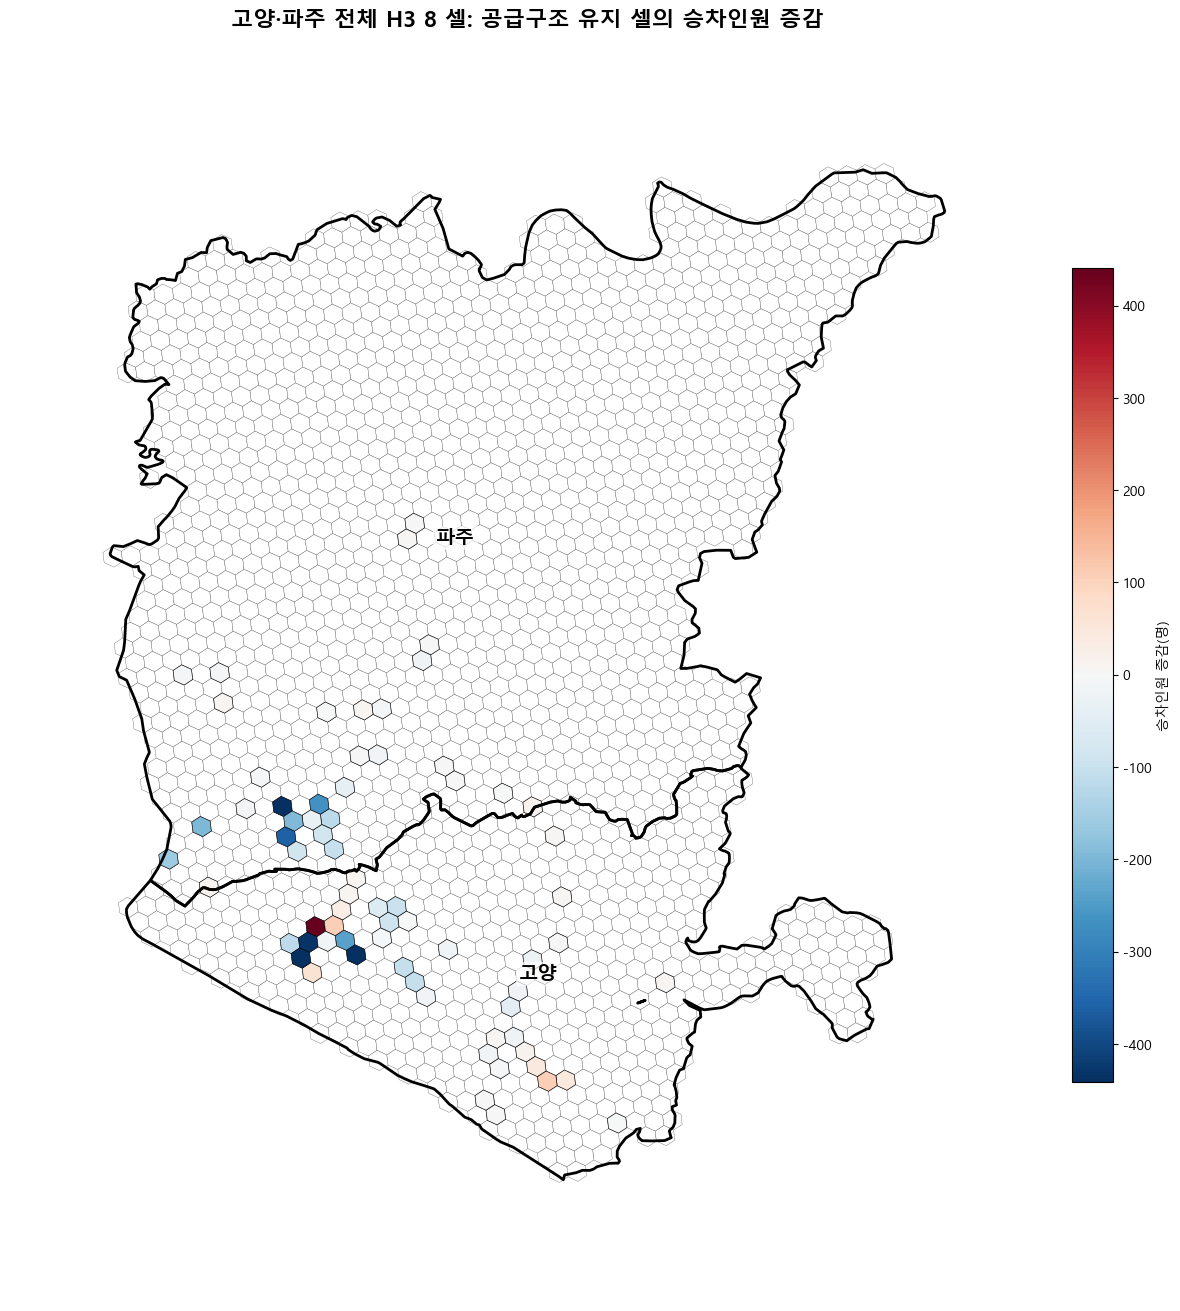

고양·파주 전체 H3 8 셀: 1883개
증감을 표시한 공급구조 유지 셀: 71개


In [13]:
target_cities = city_boundary[city_boundary['city'].isin(['고양', '파주'])].copy()
target_geometry = target_cities.geometry.union_all() if hasattr(target_cities.geometry, 'union_all') else target_cities.geometry.unary_union
city_cells = sorted(h3.geo_to_cells(mapping(target_geometry), H3_RESOLUTION), key=str)
full_city_cells = gpd.GeoDataFrame(
    {'H3 셀': city_cells},
    geometry=[h3_polygon(cell) for cell in city_cells],
    crs='EPSG:4326'
)

stable_lookup = stable_demand.set_index('H3 셀')
full_city_cells['2024 승차인원'] = full_city_cells['H3 셀'].map(stable_lookup['2024 승차인원']).fillna(0)
full_city_cells['2025 승차인원'] = full_city_cells['H3 셀'].map(stable_lookup['2025 승차인원']).fillna(0)
full_city_cells['승차인원 증감'] = full_city_cells['H3 셀'].map(stable_lookup['승차인원 증감'])
full_city_cells['승차 있음'] = full_city_cells['승차인원 증감'].notna()

valid_change = full_city_cells.loc[full_city_cells['승차 있음'], '승차인원 증감'].dropna()
change_limit = max(1, float(np.nanpercentile(np.abs(valid_change), 95))) if len(valid_change) else 1
change_norm = TwoSlopeNorm(vmin=-change_limit, vcenter=0, vmax=change_limit)

fig, ax = plt.subplots(figsize=(15, 13), constrained_layout=True)
# 승차인원이 없는 셀은 흰색으로 표시
full_city_cells[~full_city_cells['승차 있음']].plot(
    ax=ax, facecolor='white', edgecolor='#555555', linewidth=0.25
)
# 공급구조 유지 셀 중 승차인원이 있는 셀만 증감 색상으로 표시
active_city_cells = full_city_cells[full_city_cells['승차 있음']]
if len(active_city_cells):
    active_city_cells.plot(
        ax=ax, column='승차인원 증감', cmap='RdBu_r', norm=change_norm,
        edgecolor='black', linewidth=0.45, legend=True,
        legend_kwds={'label': '승차인원 증감(명)', 'shrink': 0.65, 'pad': 0.02}
    )
# 고양·파주 시 경계만 검은색으로 표시
target_cities.boundary.plot(ax=ax, color='black', linewidth=2.0)
for _, city_row in target_cities.iterrows():
    point = city_row.geometry.representative_point()
    ax.text(point.x, point.y, city_row['city'], fontsize=14, fontweight='bold', ha='center', va='center',
            bbox={'facecolor': 'white', 'edgecolor': 'none', 'alpha': 0.7, 'pad': 2})

minx, miny, maxx, maxy = target_cities.total_bounds
padx = max((maxx - minx) * 0.12, 0.02)
pady = max((maxy - miny) * 0.12, 0.02)
ax.set_xlim(minx - padx, maxx + padx)
ax.set_ylim(miny - pady, maxy + pady)
ax.set_aspect('equal')
ax.set_title('고양·파주 전체 H3 8 셀: 공급구조 유지 셀의 승차인원 증감', fontsize=16, fontweight='bold', pad=16)
ax.set_axis_off()
plt.show()

print(f'고양·파주 전체 H3 8 셀: {len(full_city_cells)}개')
print(f'증감을 표시한 공급구조 유지 셀: {len(active_city_cells)}개')


## 셀 14. GTX-A 운정중앙·킨텍스·대곡 위치와 승차인원 증감 표시

고양·파주 H3 8 승차인원 증감 지도 위에 GTX-A 북서부 3개 역만 표시한다.

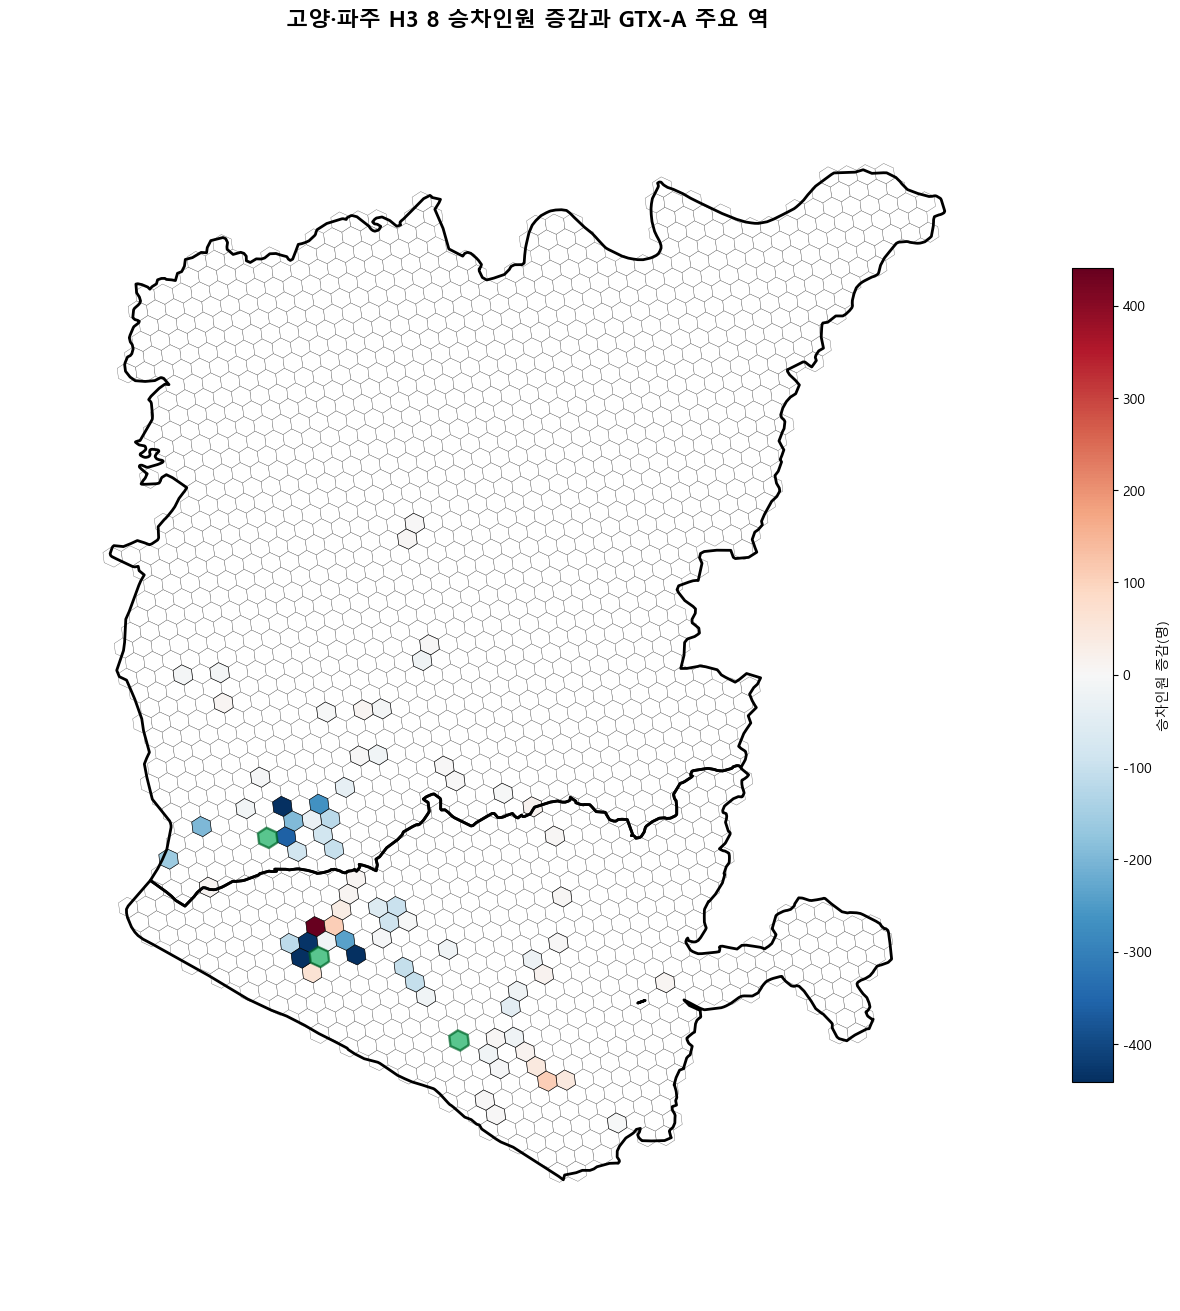

In [14]:
gtx_a_three = pd.DataFrame({
    '역명': ['운정중앙', '킨텍스', '대곡'],
    'lat': [37.716670, 37.665000, 37.631626],
    'lon': [126.728330, 126.748060, 126.811024],
})
gtx_a_three_gdf = gpd.GeoDataFrame(
    gtx_a_three,
    geometry=gpd.points_from_xy(gtx_a_three['lon'], gtx_a_three['lat']),
    crs='EPSG:4326'
)

fig, ax = plt.subplots(figsize=(15, 13), constrained_layout=True)
full_city_cells[~full_city_cells['승차 있음']].plot(
    ax=ax, facecolor='white', edgecolor='#555555', linewidth=0.25
)
if len(active_city_cells):
    active_city_cells.plot(
        ax=ax, column='승차인원 증감', cmap='RdBu_r', norm=change_norm,
        edgecolor='black', linewidth=0.45, legend=True,
        legend_kwds={'label': '승차인원 증감(명)', 'shrink': 0.65, 'pad': 0.02}
    )
target_cities.boundary.plot(ax=ax, color='black', linewidth=2.0)
station_cells = full_city_cells[full_city_cells['H3 셀'].isin({latlon_to_h3(row.lat, row.lon, 8) for row in gtx_a_three.itertuples()})]
station_cells.plot(ax=ax, facecolor='#00A651', edgecolor='#006B2C', alpha=0.65, linewidth=1.8, zorder=5)

minx, miny, maxx, maxy = target_cities.total_bounds
padx = max((maxx - minx) * 0.12, 0.02)
pady = max((maxy - miny) * 0.12, 0.02)
ax.set_xlim(minx - padx, maxx + padx)
ax.set_ylim(miny - pady, maxy + pady)
ax.set_aspect('equal')
ax.set_title('고양·파주 H3 8 승차인원 증감과 GTX-A 주요 역', fontsize=16, fontweight='bold', pad=16)
ax.set_axis_off()
plt.show()


## 셀 15. H3 7·8·9 공급구조 유지 셀 비교

H3 8에 적용한 노선번호 집합 비교와 정류장명·좌표 기반 매칭을 H3 7에도 동일하게 적용한다.

In [15]:
def analyze_h3_resolution(resolution):
    cell_col = f'h3_{resolution}'
    if cell_col not in boarding_stops.columns:
        boarding_stops[cell_col] = [latlon_to_h3(lat, lon, resolution) for lat, lon in zip(boarding_stops['lat'], boarding_stops['lon'])]
    # 수요 집계용 데이터에도 현재 해상도의 H3 셀 ID를 반드시 생성한다.
    if cell_col not in boarding_for_change.columns:
        boarding_for_change[cell_col] = [latlon_to_h3(lat, lon, resolution) for lat, lon in zip(boarding_for_change['lat'], boarding_for_change['lon'])]
    # 노선 구성 비교에서는 같은 정류장을 여러 노선이 이용하는 경우를 보존한다.
    year_stops_res = boarding_stops.drop_duplicates(['year', 'route_no', 'stop_id']).copy()
    route_sets = year_stops_res.groupby([cell_col, 'year'])['route_no'].agg(lambda x: set(x.astype(str))).unstack(fill_value=None)
    for year in [2024, 2025]:
        if year not in route_sets.columns:
            route_sets[year] = None
    route_sets[2024] = route_sets[2024].apply(lambda x: x if isinstance(x, set) else set())
    route_sets[2025] = route_sets[2025].apply(lambda x: x if isinstance(x, set) else set())
    all_cells_res = sorted(set(route_sets.index), key=str)

    def stop_configuration_changed(cell):
        before = year_stops_res[(year_stops_res[cell_col] == cell) & (year_stops_res['year'] == 2024)].drop_duplicates('stop_id').copy()
        after = year_stops_res[(year_stops_res[cell_col] == cell) & (year_stops_res['year'] == 2025)].drop_duplicates('stop_id').copy()
        before['name_key'] = before['stop_name'].map(normalize_stop_name_for_compare)
        after['name_key'] = after['stop_name'].map(normalize_stop_name_for_compare)
        common_names = set(before['name_key']) & set(after['name_key'])
        before_unmatched = before[~before['name_key'].isin(common_names)].copy()
        after_unmatched = after[~after['name_key'].isin(common_names)].copy()
        while len(before_unmatched) and len(after_unmatched):
            pairs = [(distance_m(b['lat'], b['lon'], a['lat'], a['lon']), bi, ai)
                     for bi, b in before_unmatched.iterrows()
                     for ai, a in after_unmatched.iterrows()]
            distance, before_idx, after_idx = min(pairs, key=lambda x: x[0])
            if distance <= MATCH_DISTANCE_M:
                before_unmatched = before_unmatched.drop(index=before_idx)
                after_unmatched = after_unmatched.drop(index=after_idx)
            else:
                break
        return int(len(before_unmatched) > 0 or len(after_unmatched) > 0)

    rows = []
    for cell in all_cells_res:
        routes24 = route_sets.loc[cell, 2024] if cell in route_sets.index else set()
        routes25 = route_sets.loc[cell, 2025] if cell in route_sets.index else set()
        route_changed = int(routes24 != routes25)
        stop_changed = stop_configuration_changed(cell)
        rows.append({'H3 셀': cell, '노선구성 변경 여부': route_changed, '정류장구성 변경 여부': stop_changed})
    structure = pd.DataFrame(rows)
    stable_cells_res = structure.loc[(structure['노선구성 변경 여부'] == 0) & (structure['정류장구성 변경 여부'] == 0), 'H3 셀'].tolist()

    demand_res = boarding_for_change.groupby([cell_col, 'year'])['boarding_users'].sum().unstack(fill_value=0)
    for year in [2024, 2025]:
        if year not in demand_res.columns:
            demand_res[year] = 0
    demand_res = demand_res.reindex(stable_cells_res, fill_value=0)[[2024, 2025]]
    demand_res.columns = ['2024 승차인원', '2025 승차인원']
    demand_res['승차인원 증감'] = demand_res['2025 승차인원'] - demand_res['2024 승차인원']
    demand_res = demand_res.reset_index().rename(columns={cell_col: 'H3 셀'})
    return structure, stable_cells_res, demand_res

resolution_results = {}
comparison_rows = []
for resolution in [7, 8, 9]:
    structure_res, stable_cells_res, demand_res = analyze_h3_resolution(resolution)
    resolution_results[resolution] = {'structure': structure_res, 'stable_demand': demand_res}
    valid_changes = demand_res['승차인원 증감'].dropna()
    extreme = valid_changes.abs() > 100
    comparison_rows.append({
        'H3 해상도': resolution,
        '전체 셀 수': len(structure_res),
        '공급구조 유지 셀 수': len(demand_res),
        '공급구조 유지 비율(%)': len(demand_res) / len(structure_res) * 100,
        '2024 승차인원 중앙값': demand_res['2024 승차인원'].median(),
        '승차인원 증감 중앙값': valid_changes.median(),
        '승차인원 증감 IQR': valid_changes.quantile(0.75) - valid_changes.quantile(0.25),
        '|증감|>100명 셀 수': int(extreme.sum()),
        '|증감|>100명 비율(%)': extreme.mean() * 100 if len(extreme) else np.nan,
    })

resolution_comparison = pd.DataFrame(comparison_rows).set_index('H3 해상도')
print('H3 7·8·9 공급구조 유지 셀 비교')
display(resolution_comparison.round(2))

for resolution, result in resolution_results.items():
    result['stable_demand'].to_csv(OUTPUT_DIR / f'h3_{resolution}_stable_supply_demand_change.csv', index=False, encoding='utf-8-sig')
resolution_comparison.reset_index().to_csv(OUTPUT_DIR / 'h3_7_8_9_supply_structure_comparison.csv', index=False, encoding='utf-8-sig')


H3 7·8·9 공급구조 유지 셀 비교


,전체 셀 수,공급구조 유지 셀 수,공급구조 유지 비율(%),2024 승차인원 중앙값,승차인원 증감 중앙값,승차인원 증감 IQR,|증감|>100명 셀 수,|증감|>100명 비율(%)
H3 해상도,,,,,,,,
7,65,20,30.77,42.0,-8.5,30.5,5,25.00
8,146,71,48.63,91.0,-9.0,90.5,18,25.35
9,231,131,56.71,69.0,-5.0,38.0,17,12.98


## 셀 16. H3 7·8·9 셀별 승차인원 증감 비교

변화율 대신 `승차인원 증감 = 2025년 승차인원 - 2024년 승차인원`을 주 분석 지표로 사용한다.

H3 7·8·9 공급구조 유지 셀의 승차인원 증감 비교


,전체 셀 수,공급구조 유지 셀 수,공급구조 유지 비율(%),2024 승차인원 중앙값,승차인원 증감 중앙값,승차인원 증감 IQR,|증감|>100명 셀 수,|증감|>100명 비율(%)
H3 해상도,,,,,,,,
7,65,20,30.77,42.0,-8.5,30.5,5,25.00
8,146,71,48.63,91.0,-9.0,90.5,18,25.35
9,231,131,56.71,69.0,-5.0,38.0,17,12.98


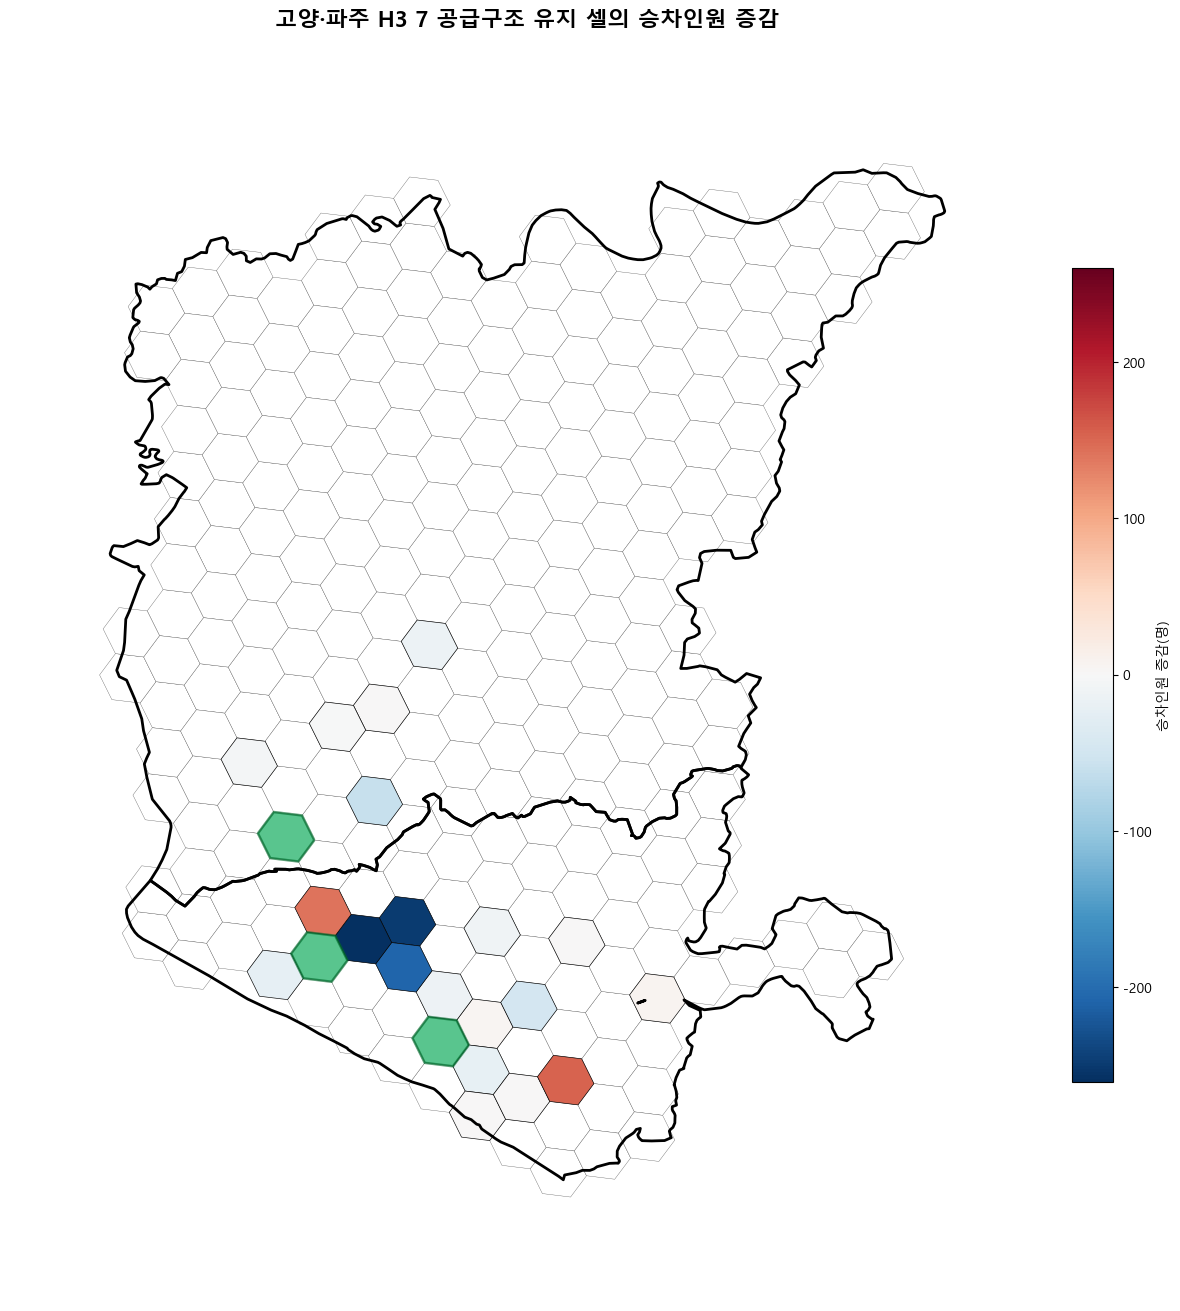

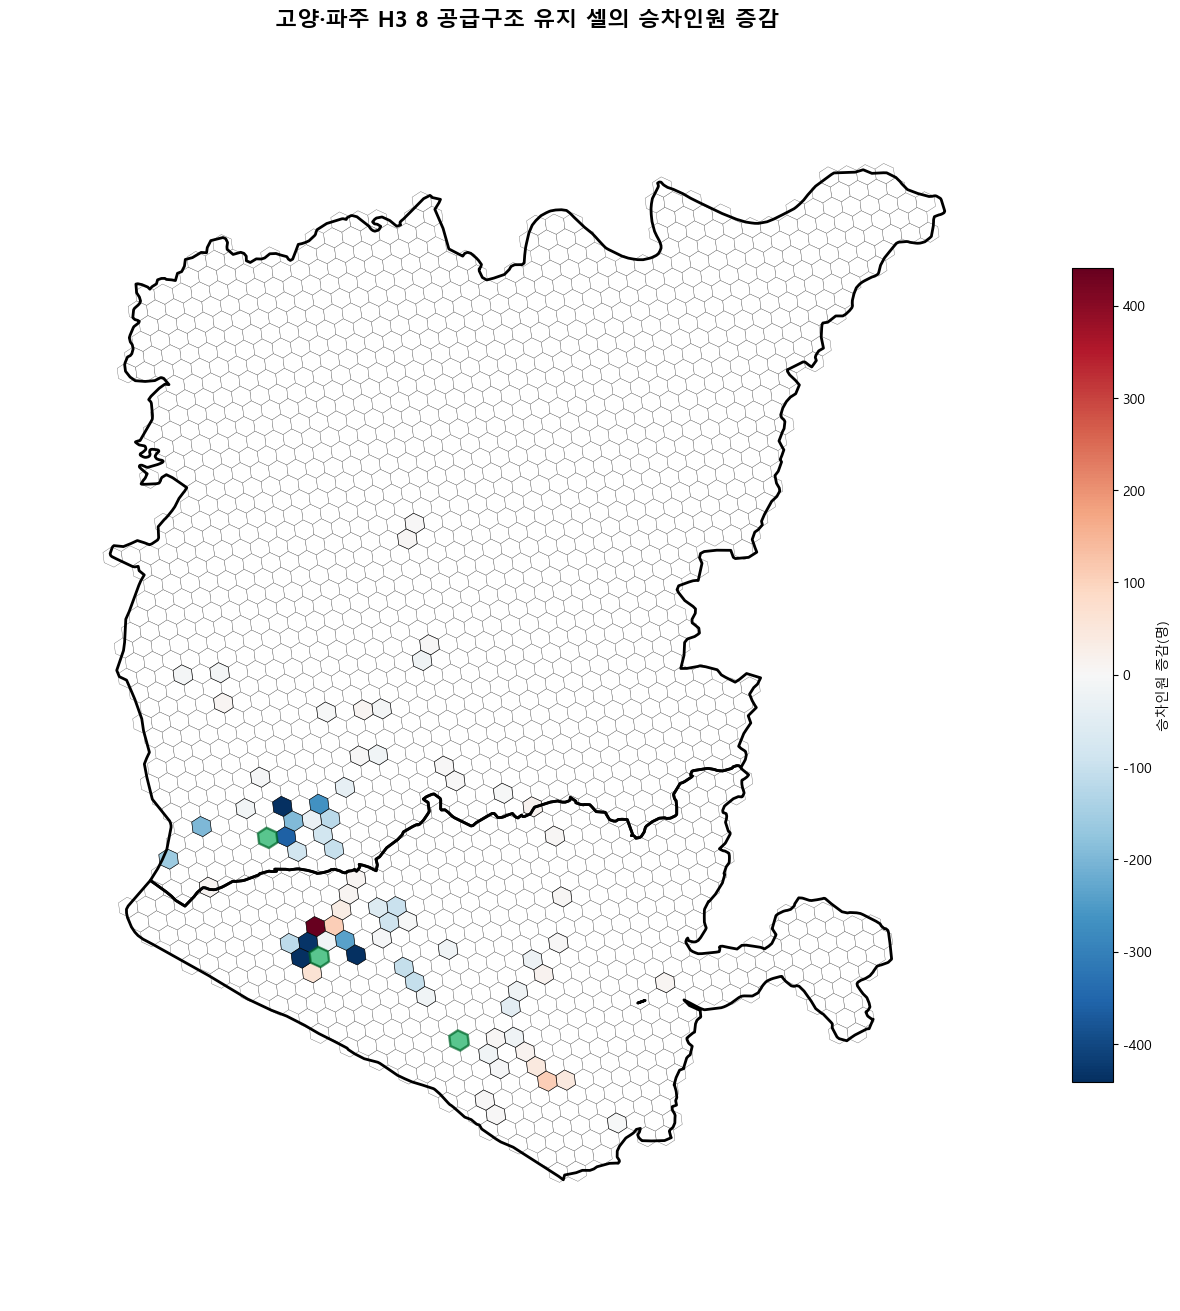

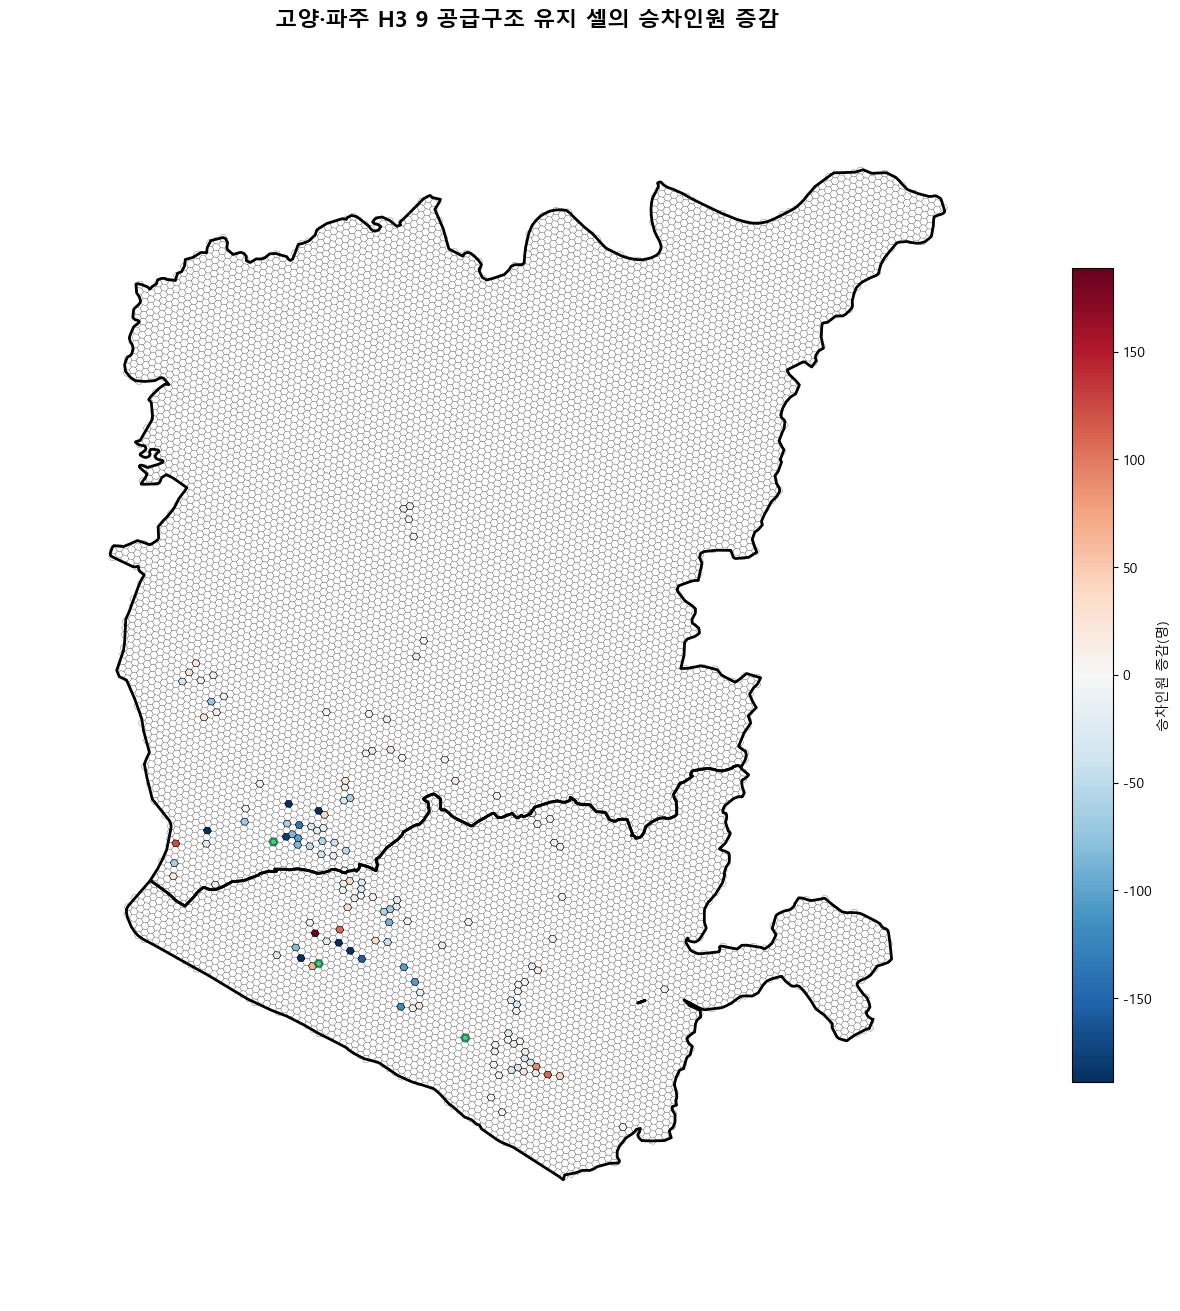

In [16]:
ABS_CHANGE_THRESHOLD = 100
absolute_comparison_rows = []
for resolution, result in resolution_results.items():
    demand_res = result['stable_demand'].copy()
    change = demand_res['승차인원 증감']
    extreme = change.abs() > ABS_CHANGE_THRESHOLD
    absolute_comparison_rows.append({
        'H3 해상도': resolution,
        '전체 셀 수': len(result['structure']),
        '공급구조 유지 셀 수': len(demand_res),
        '공급구조 유지 비율(%)': len(demand_res) / len(result['structure']) * 100,
        '2024 승차인원 중앙값': demand_res['2024 승차인원'].median(),
        '승차인원 증감 중앙값': change.median(),
        '승차인원 증감 IQR': change.quantile(0.75) - change.quantile(0.25),
        '|증감|>100명 셀 수': int(extreme.sum()),
        '|증감|>100명 비율(%)': extreme.mean() * 100,
    })

absolute_comparison = pd.DataFrame(absolute_comparison_rows).set_index('H3 해상도')
print('H3 7·8·9 공급구조 유지 셀의 승차인원 증감 비교')
display(absolute_comparison.round(2))

def plot_absolute_change_map(resolution):
    demand_res = resolution_results[resolution]['stable_demand']
    demand_lookup = demand_res.set_index('H3 셀')
    cell_col = f'h3_{resolution}'
    if cell_col not in boarding_stops.columns:
        boarding_stops[cell_col] = [latlon_to_h3(lat, lon, resolution) for lat, lon in zip(boarding_stops['lat'], boarding_stops['lon'])]
    city_cells_res = sorted(h3.geo_to_cells(mapping(target_geometry), resolution), key=str)
    map_res = gpd.GeoDataFrame({'H3 셀': city_cells_res}, geometry=[h3_polygon(cell) for cell in city_cells_res], crs='EPSG:4326')
    map_res['승차인원 증감'] = map_res['H3 셀'].map(demand_lookup['승차인원 증감'])
    map_res['증감 관측'] = map_res['승차인원 증감'].notna()
    active = map_res[map_res['증감 관측']]
    max_abs = max(1, float(np.nanpercentile(np.abs(active['승차인원 증감']), 95))) if len(active) else 1
    
    norm = TwoSlopeNorm(vmin=-max_abs, vcenter=0, vmax=max_abs)
    fig, ax = plt.subplots(figsize=(15, 13), constrained_layout=True)
    map_res[~map_res['증감 관측']].plot(ax=ax, facecolor='white', edgecolor='#555555', linewidth=0.25)
    if len(active):
        active.plot(ax=ax, column='승차인원 증감', cmap='RdBu_r', norm=norm, edgecolor='black', linewidth=0.45, legend=True,
                    legend_kwds={'label': '승차인원 증감(명)', 'shrink': 0.65, 'pad': 0.02})
    target_cities.boundary.plot(ax=ax, color='black', linewidth=2.0)
    if 'gtx_a_three_gdf' in globals():
        station_cells = map_res[map_res['H3 셀'].isin({latlon_to_h3(row.lat, row.lon, resolution) for row in gtx_a_three.itertuples()})]
        station_cells.plot(ax=ax, facecolor='#00A651', edgecolor='#006B2C', alpha=0.65, linewidth=1.8, zorder=5)
    minx, miny, maxx, maxy = target_cities.total_bounds
    padx, pady = max((maxx - minx) * 0.12, 0.02), max((maxy - miny) * 0.12, 0.02)
    ax.set_xlim(minx - padx, maxx + padx)
    ax.set_ylim(miny - pady, maxy + pady)
    ax.set_aspect('equal')
    ax.set_title(f'고양·파주 H3 {resolution} 공급구조 유지 셀의 승차인원 증감', fontsize=16, fontweight='bold', pad=16)
    ax.set_axis_off()
    plt.show()

plot_absolute_change_map(7)
plot_absolute_change_map(8)
plot_absolute_change_map(9)
absolute_comparison.reset_index().to_csv(OUTPUT_DIR / 'h3_7_8_9_supply_structure_absolute_change_comparison.csv', index=False, encoding='utf-8-sig')
